<a href="https://colab.research.google.com/github/abeeraz379/Clickstream-prediction-for-Online-Shopping-Project/blob/main/Clickstream_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clickstream Data for Online Shopping Project

- Data Link : https://archive.ics.uci.edu/dataset/553/clickstream+data+for+online+shopping




## Data Dictionary
Data description “e-shop clothing 2008”

Variables:

1. YEAR (2008)
2. MONTH -> from April (4) to August (8)
3. DAY -> day number of the month
4. ORDER -> sequence of clicks during one session
5. COUNTRY -> variable indicating the country of origin of the IP address
6. SESSION ID -> variable indicating session id (short record)
7. PAGE 1 (MAIN CATEGORY) -> concerns the main product category
8. PAGE 2 (CLOTHING MODEL) -> contains information about the code for each product
(217 products)
9. COLOUR -> colour of product
10. LOCATION -> photo location on the page, the screen has been divided into six parts
11. MODEL PHOTOGRAPHY -> variable with two categories
12. PRICE -> price in US dollars
13. PRICE 2 -> variable informing whether the price of a particular product is higher than
the average price for the entire product category
14. PAGE -> page number within the e-store website (from 1 to 5)


## The Target is **order**
- Regression task
- The goal is to increase no. of clicks during one session


# Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns

from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn import set_config
set_config(transform_output='pandas')

import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.activations import relu

import warnings
warnings.filterwarnings('ignore')

# Load and inspect data

In [2]:
df =pd.read_csv('/content/drive/MyDrive/NLP/e_shop_clothing_2008.csv',sep=";")
df.head()

,year,month,day,order,country,session ID,page 1 (main category),page 2 (clothing model),colour,location,model photography,price,price 2,page
0,2008,4,1,1,29,1,1,A13,1,5,1,28,2,1
1,2008,4,1,2,29,1,1,A16,1,6,1,33,2,1
2,2008,4,1,3,29,1,2,B4,10,2,1,52,1,1
3,2008,4,1,4,29,1,2,B17,6,6,2,38,2,1
4,2008,4,1,5,29,1,2,B8,4,3,2,52,1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165474 entries, 0 to 165473
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   year                     165474 non-null  int64 
 1   month                    165474 non-null  int64 
 2   day                      165474 non-null  int64 
 3   order                    165474 non-null  int64 
 4   country                  165474 non-null  int64 
 5   session ID               165474 non-null  int64 
 6   page 1 (main category)   165474 non-null  int64 
 7   page 2 (clothing model)  165474 non-null  object
 8   colour                   165474 non-null  int64 
 9   location                 165474 non-null  int64 
 10  model photography        165474 non-null  int64 
 11  price                    165474 non-null  int64 
 12  price 2                  165474 non-null  int64 
 13  page                     165474 non-null  int64 
dtypes: int64(13), object

## unique values for each feature

In [4]:
# show each feature with his values
for col in df.columns:
  print(f"{col} : {df[col].unique()}")

year : [2008]
month : [4 5 6 7 8]
day : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
order : [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195]
country : [29 21  9 16 38 24 41 12 31 44 34 28 46 15 10 27  7 25

## check Missing values

In [5]:
df.isna().sum()

,0
year,0
month,0
day,0
order,0
country,0
session ID,0
page 1 (main category),0
page 2 (clothing model),0
colour,0
location,0


## check duplicated

In [6]:
df.duplicated().sum()

np.int64(0)

# Data visualization

In [7]:
target='order'

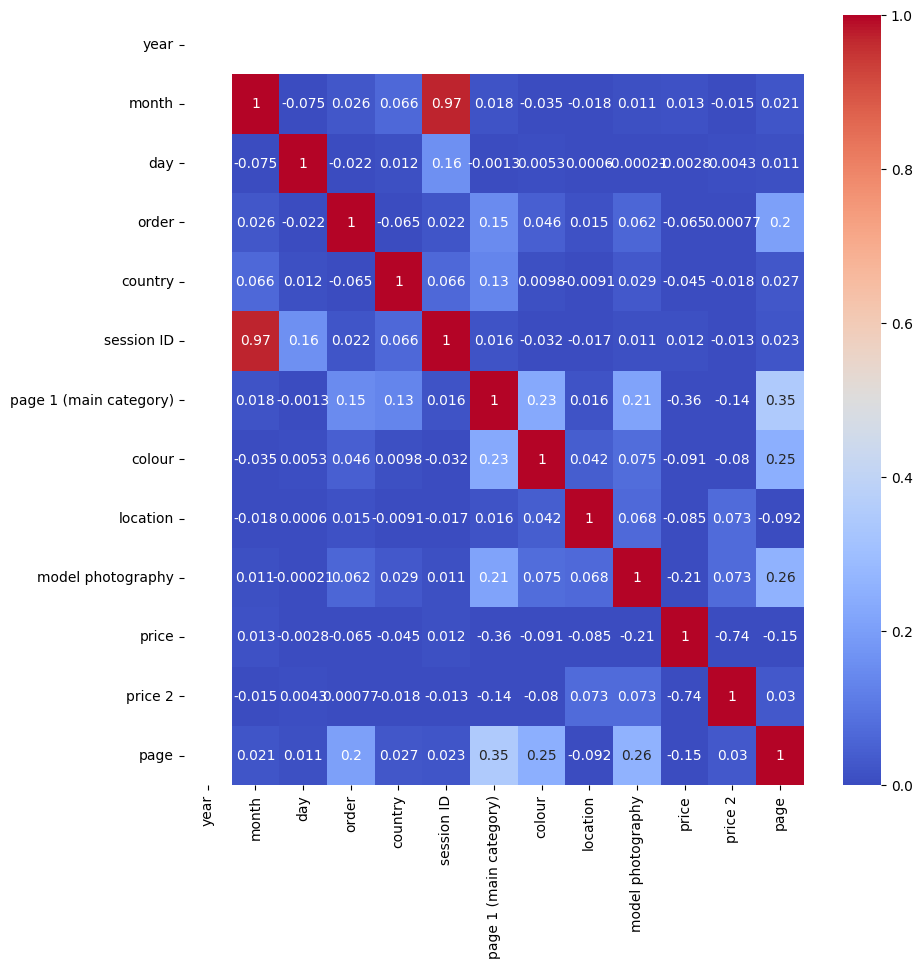

In [8]:
# Creatre heatmap
plt.figure(figsize=(10,10))

num_cols = df.select_dtypes(include=['number']).columns
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.show()

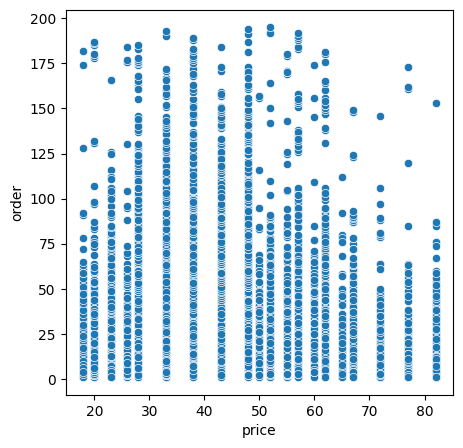

In [9]:
# check relationship between features and target
fig, ax = plt.subplots(figsize=(5, 5))
sns.scatterplot(data=df, x='price', y='order', ax=ax)
plt.show()

## most clickstream for product with price 30 to 45 $

<Axes: xlabel='page', ylabel='order'>

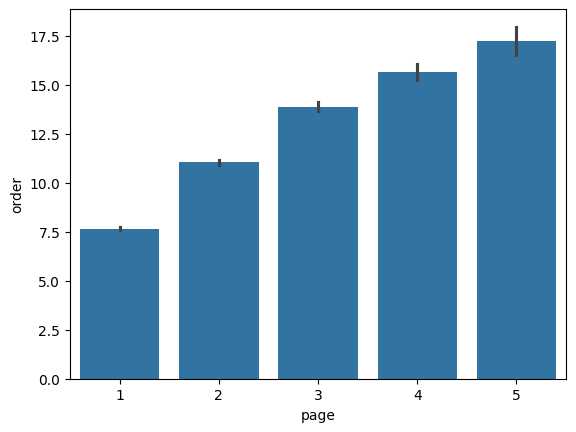

In [10]:
sns.barplot(data=df, x='page', y='order')

<Axes: xlabel='month', ylabel='order'>

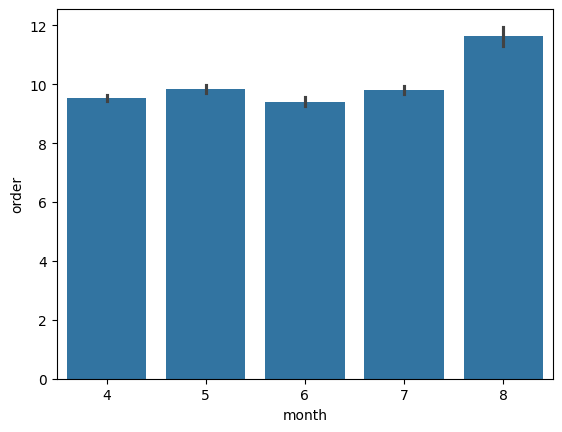

In [11]:
sns.barplot(data=df, x='month', y='order')

<Axes: xlabel='day', ylabel='order'>

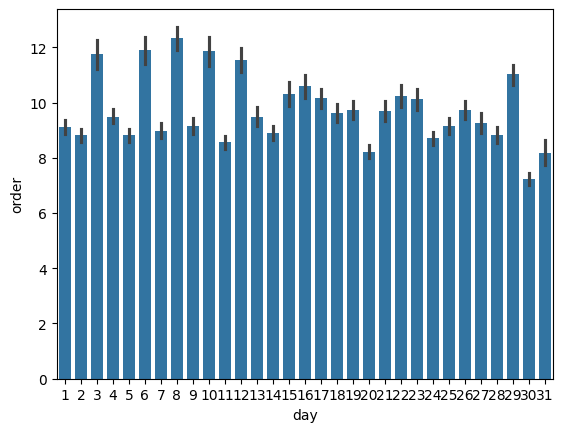

In [12]:
sns.barplot(data=df, x='day', y='order')

<Axes: xlabel='country', ylabel='order'>

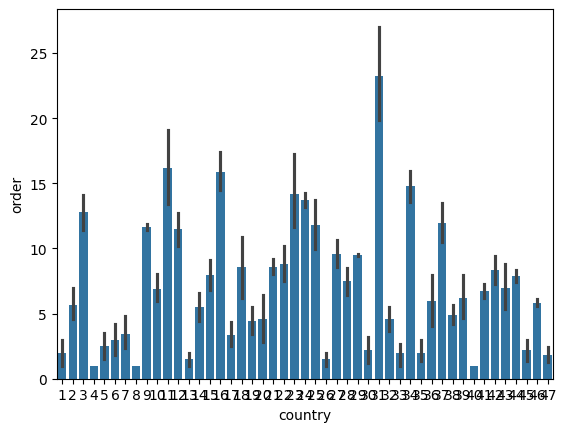

In [13]:
sns.barplot(data=df, x='country', y='order')

# Preprocessing

## define x and y

In [14]:
df['order'].value_counts()

,count
order,
1,24026
2,18984
3,15664
4,13044
5,11007
...,...
191,2
192,2
193,1


In [15]:

X=df.drop(["order", "session ID", "year",'page 2 (clothing model)'], axis=1)
y=df['order']

## Split data

In [16]:
# Split the data into training and testing sets
x_train, x_test_val, y_train, y_test_val = train_test_split(X, y, test_size = .3,
random_state=42, shuffle =True)

In [17]:
# Split the x_test_val into test and val data
x_val, x_test, y_val, y_test = train_test_split(x_test_val, y_test_val, test_size
= .5, random_state=42)

## OrdinalEncoder

In [18]:
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_train[['page 2 (clothing model)']] = encoder.fit_transform(
    x_train[['page 2 (clothing model)']]
)

x_test[['page 2 (clothing model)']] = encoder.transform(
    x_test[['page 2 (clothing model)']]
)

x_val[['page 2 (clothing model)']] = encoder.transform(
    x_val[['page 2 (clothing model)']]
)

KeyError: "None of [Index(['page 2 (clothing model)'], dtype='object')] are in the [columns]"

In [ ]:
x_train[['page 2 (clothing model)']].value_counts()

## Scaling

In [19]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)


In [20]:

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
y_val_log = np.log1p(y_val)

# Build model

In [21]:
input_shape = x_train. shape[1]
input_shape

10

In [22]:

model = keras.models.Sequential([
    Dense(32, input_dim=input_shape, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='softplus')
])


## Compile

In [23]:

model.compile(

    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)



In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 64 (256.00 B)

In [25]:

early_stop = EarlyStopping(monitor='val_loss', patience=15,restore_best_weights=True)

## fit

In [27]:

history = model.fit(
    x_train, y_train_log,
    validation_data=(x_val, y_val_log),
    epochs=50,
    batch_size=1000,
    callbacks=[early_stop]
)


Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - loss: 1.5229 - mae: 0.9721 - val_loss: 1.3819 - val_mae: 0.9260
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1413 - mae: 0.8461 - val_loss: 1.0603 - val_mae: 0.8089
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.0290 - mae: 0.8063 - val_loss: 0.9135 - val_mae: 0.7545
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9702 - mae: 0.7855 - val_loss: 0.8557 - val_mae: 0.7330
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9332 - mae: 0.7721 - val_loss: 0.8081 - val_mae: 0.7158
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9000 - mae: 0.7597 - val_loss: 0.7868 - val_mae: 0.7081
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8788 - mae: 0.7516 - val_loss: 0.7749 - val_mae: 0.7042
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8557 - mae: 0.7431 - val_loss: 0.7698 - val_mae: 0.7028
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - 

# History plot

In [28]:
def plot_history(history, figsize=(6, 12), marker='o'):
    # Get list of metrics from history (exclude val_ keys)
    metrics = [c for c in history.history.keys() if not c.startswith('val_')]

    # Create one subplot per metric
    fig, axes = plt.subplots(nrows=len(metrics), figsize=figsize, squeeze=False)
    axes = axes.flatten()  # Make axes easy to index even if len(metrics)==1

    # For each metric
    for i, metric_name in enumerate(metrics):
        ax = axes[i]

        # Get metric values from history
        train_values = history.history[metric_name]
        epochs = range(len(train_values))  # or history.epoch if available

        # Plot training metric
        ax.plot(epochs, train_values, label=metric_name, marker=marker)

        # Check if val_{metric} exists and plot validation curve
        val_metric_name = f"val_{metric_name}"
        if val_metric_name in history.history:
            val_values = history.history[val_metric_name]
            ax.plot(epochs, val_values, label=val_metric_name, marker=marker)

        # Final subplot adjustments
        ax.legend()
        ax.set_title(metric_name)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_name)

    fig.tight_layout()
    return fig, axes

# Evaluation

In [29]:
model.evaluate(x_test, y_test_log)

776/776 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7131 - mae: 0.6882


[0.7131010890007019, 0.6881570219993591]

In [30]:
y_pred_log = model.predict(x_test)
y_pred = np.expm1(y_pred_log)



776/776 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


(<Figure size 600x1200 with 2 Axes>,
 array([<Axes: title={'center': 'loss'}, xlabel='Epoch', ylabel='loss'>,
        <Axes: title={'center': 'mae'}, xlabel='Epoch', ylabel='mae'>],
       dtype=object))

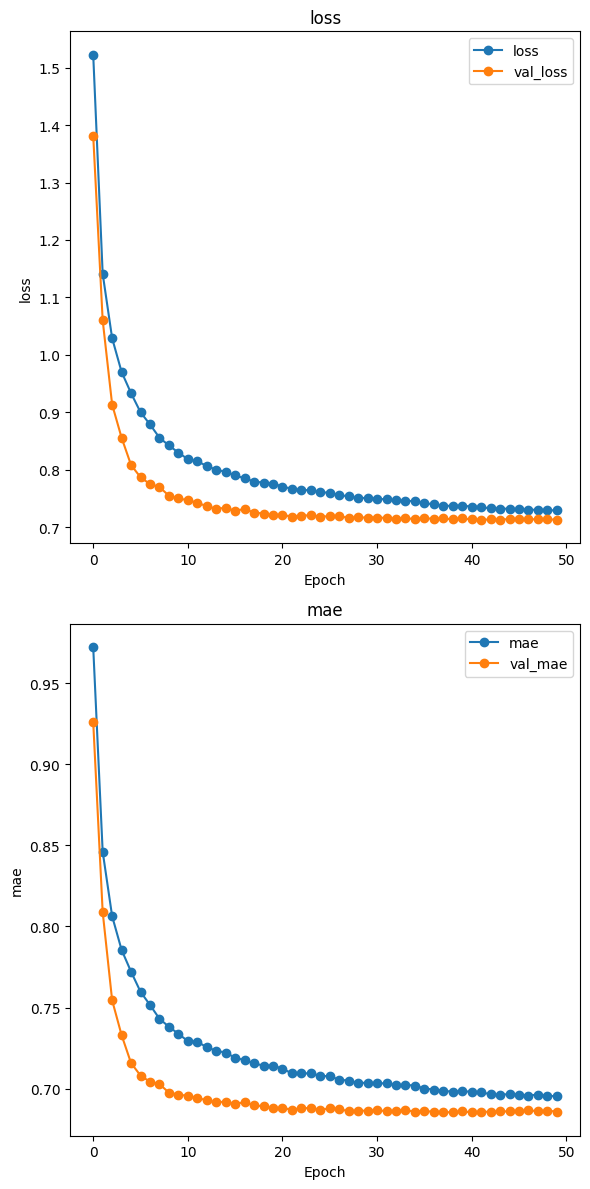

In [31]:
plot_history(history)

In [32]:
print('Prediction items are {}'.format(y_pred[:10]))
print('Real items are {}'.format(y_test[:10]))

Prediction items are [[ 3.7063403]
 [ 4.750991 ]
 [ 6.0426946]
 [ 5.297767 ]
 [10.836743 ]
 [ 4.2859907]
 [ 3.8596334]
 [ 6.7660546]
 [ 7.4606442]
 [ 3.6019762]]
Real items are 26735      4
41642      2
86172      1
34310      2
141623    11
94110      2
37059      5
4375       9
25385      7
48968     20
Name: order, dtype: int64
